# Shape Detection
This project is intended as a precursor to doing particle detection on synthetic and then real microscope data, and this simple test case is used to be the first step in the process.
## The Problem
The research I work in is in biophysics. The project I have been spending time on has to do with DNA origami, which are structures we create out of DNA. The workflow of research is:
<br>
- Design Structure
- Create Structures
- Image Structures
- Analyze Images
<br><br>
Designing these structures involves a good amount of work, but once you are done with that making them just involves mixing specific strands of DNA at the correct concentrations. So there is upfront work to this, but once done with that, you can make millions of structures very easily. Then you must prepare samples for imaging, and then imaging structures requires going to a microscope with prepared samples. This takes time but is necessary. Next, the images, which contain on the order of 100 structures, must be processed. There are 2 general steps for this: particle detection and particle characterization. My lab already has methods to automate the particle characterization, but particle detection is still largely done by hand. So, this notebook will focus on automating the problem of particle detection. The time spent between preparing samples, imaging samples, and characterizing samples is roughly equal, so if the analysis is fully automated, optimistically this cuts off a third of the time needed to get data.
<br><br>
So, on to the specific problem. We are given an image of many particles.
- Some form into clusters, which we do not want to take data from. We want to just keep particles with no others around them.
- There may be some other particles that we do not want to detect.
- There is noise in the background
<br><br>
What we want to eventually do is get cropped images of the good particles, to feed to another algorithm to characterize. For now, just detecting good particles will suffice.

## Simplifying the Problem as a Test Case
Rather than working with experimental data from the beginning, I will generate a simplified mock data, consisting of rectangles that we want to detect, and circles we want to ignore. The background will also have some noise.The rectangles can be oriented in any direction, but are always the same size. They can also generate on top of each other. The circles can be various sizes.

## The Approach
I will use a neural net to try to find the locations of the rectangles in the image.

In [1]:
#imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
import numpy as np
import cv2
import matplotlib.patches as patches
import itertools
from scipy.optimize import linear_sum_assignment

# Mock Data

In [2]:
#Class to generate Mock Data.
#Random number generation is done deterministically, so that when images are pulled at different parts they will be the same.
class ShapesDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        img_size=128,
        max_rects=3,
        max_circles=3,
        rect_w=40,
        rect_h=6,
        noise_std=0.05,
        length=1000
    ):
        self.img_size = img_size
        self.max_rects = max_rects
        self.max_circles = max_circles
        self.rect_w = rect_w
        self.rect_h = rect_h
        self.noise_std = noise_std
        self.length = length

    def _draw_rotated_rectangle(self, img, rng):
        cx = rng.randint(20, self.img_size - 20)
        cy = rng.randint(20, self.img_size - 20)
        angle = rng.uniform(-np.pi/2, np.pi/2)

        rect = ((cx, cy), (self.rect_w, self.rect_h), np.degrees(angle))
        box = cv2.boxPoints(rect).astype(np.int32)
        cv2.fillPoly(img, [box], color=255)

        return [cx, cy, angle]

    def _draw_circle(self, img, rng):
        r = rng.randint(6, 12)
        cx = rng.randint(r, self.img_size - r)
        cy = rng.randint(r, self.img_size - r)
        cv2.circle(img, (cx, cy), r, color=180, thickness=-1)

    def __getitem__(self, idx):
        rng = np.random.RandomState(idx)

        img = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        boxes = []

        n_rects = rng.randint(1, self.max_rects + 1)
        for _ in range(n_rects):
            boxes.append(self._draw_rotated_rectangle(img, rng))

        #n_circles = rng.randint(0, self.max_circles + 1)
        #for _ in range(n_circles):
        #    self._draw_circle(img, rng)

        img = img.astype(np.float32) / 255.0
        img += rng.normal(0, self.noise_std, img.shape)
        img = np.clip(img, 0, 1)

        img = torch.from_numpy(img).unsqueeze(0)
        boxes = torch.tensor(boxes, dtype=torch.float32)

        return img, boxes

    def __len__(self):
        return self.length



class WrappedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, K):
        self.base = base_dataset
        self.K = K
        self.img_size = base_dataset.img_size

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, boxes = self.base[idx]
        target = boxes_to_targets(
            boxes,
            K=self.K,
            img_size=self.img_size
        )
        return img, target

In [3]:
dataset = ShapesDataset()

img1, boxes1 = dataset[0]
img2, boxes2 = dataset[0]

print(torch.allclose(img1, img2))
print((boxes1 == boxes2))

True
tensor([[True, True, True]])


In [4]:
#Rectangle Drawer for visualization
def draw_rotated_rect(ax, cx, cy, w, h, angle_rad, color="lime", lw=2, alpha=0.9):
    cx = float(cx)
    cy = float(cy)
    w = float(w)
    h = float(h)
    angle_rad = float(angle_rad)

    rect = ((cx, cy), (w, h), np.degrees(angle_rad))
    box = cv2.boxPoints(rect)

    poly = patches.Polygon(
        box,
        closed=True,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        alpha=alpha
    )
    ax.add_patch(poly)

## Visualize Data
In green are the true rectangles for the image. They are aligned with the white rectangles in the image. Further below is a single image of data.

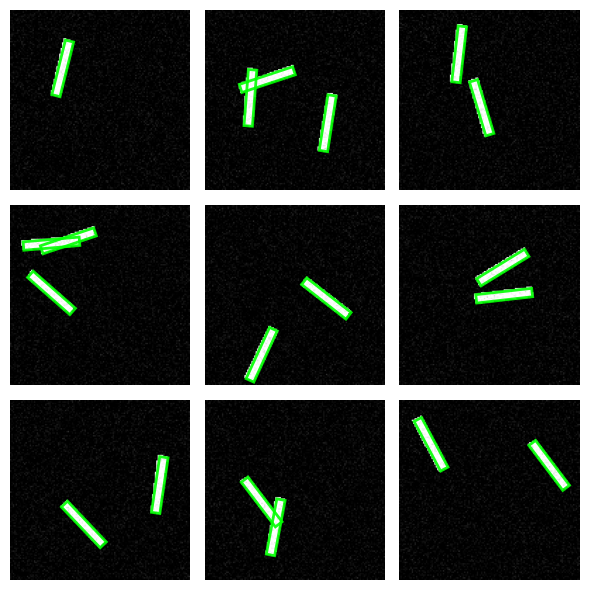

In [5]:
dataset = ShapesDataset()
img, boxes = dataset[0]

fig, axs = plt.subplots(3, 3, figsize=(6, 6))
for ax in axs.flat:
    img_tensor, boxes = dataset[random.randint(0, len(dataset)-1)]
    img_np = img_tensor.squeeze().cpu().numpy()
    ax.imshow(img_np, cmap='gray')
    for cx, cy, ang in boxes:
        draw_rotated_rect(
            ax,
            cx, cy,
            dataset.rect_w,
            dataset.rect_h,
            ang,
            color="lime"
        )
    ax.axis('off')
plt.tight_layout()
plt.show()

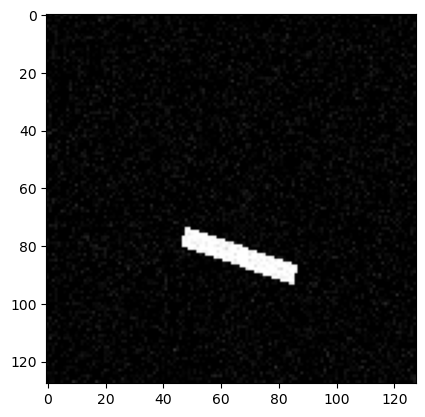

In [6]:
dataset = ShapesDataset()
img, boxes = dataset[0]

plt.imshow(img.squeeze().numpy(), cmap="gray")
plt.show()

# Neural Net


In [10]:
#Build the base of the neural net
class RectDetector(nn.Module):
    def __init__(self, K=3):
        super().__init__()
        self.K = K
        
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
    
        self.fc = nn.Linear(128, K * 5)
#    def forward(self, x):
#        feat = self.backbone(x)
#        feat = feat.view(x.size(0), -1)
#        out = self.fc(feat)
#        out = out.view(-1, self.K, 4)
#        out[..., 3] = torch.sigmoid(out[..., 3])
#        return out
    def forward(self, x):
        B = x.size(0)
        
        feat = self.backbone(x)
        feat = feat.view(B, -1)
        
        out = self.fc(feat)
        out = out.view(B, self.K, 5)
        
        # normalize sin/cos to unit length
        sin_cos = out[..., 2:4]
        sin_cos = sin_cos / (sin_cos.norm(dim=-1, keepdim=True) + 1e-6)
        out[..., 2:4] = sin_cos
         
        # confidence in [0,1]
        out[..., 4] = torch.sigmoid(out[..., 4])

        return out

def box_cost(pred, gt):
    # pred, gt: (..., 3) → cx, cy, angle
    return (
        (pred[:, None, 0] - gt[None, :, 0])**2 +
        (pred[:, None, 1] - gt[None, :, 1])**2 +
        0.1 * (pred[:, None, 2] - gt[None, :, 2])**2
    )


def hungarian_match_cost(pred_xy, gt_xy):
    """
    pred_xy: (K, 2)
    gt_xy:   (N, 2)
    returns: indices of matched predictions (row_ind) and corresponding gt indices (col_ind)
    """
    K, N = pred_xy.shape[0], gt_xy.shape[0]
    if K > N:
        raise ValueError("Number of predictions K cannot exceed number of ground truths N")

    # compute pairwise distances on CPU to use itertools safely
    pred_cpu = pred_xy.detach().cpu()
    gt_cpu = gt_xy.detach().cpu()

    min_cost = float('inf')
    best_perm = None

    for perm in itertools.permutations(range(N), K):
        cost = torch.norm(pred_cpu - gt_cpu[list(perm)], dim=1).pow(2).sum().item()
        if cost < min_cost:
            min_cost = cost
            best_perm = perm

    row_ind = torch.arange(K, device=pred_xy.device)
    col_ind = torch.tensor(best_perm, device=pred_xy.device)
    return row_ind, col_ind

def matched_rect_loss(preds, targets,
                       lambda_geom=5.0,
                       lambda_angle=1.0,
                       lambda_conf=0.2):
    B, K, _ = preds.shape
    total_loss = 0.0

    for b in range(B):
        pred = preds[b]
        tgt  = targets[b]

        pred_xy   = pred[:, :2]
        pred_ang  = pred[:, 2:4]
        pred_conf = pred[:, 4]

        tgt_xy   = tgt[:, :2]
        tgt_ang  = tgt[:, 2:4]
        tgt_conf = tgt[:, 4] > 0.5

        gt_xy  = tgt_xy[tgt_conf]
        gt_ang = tgt_ang[tgt_conf]

        # no objects
        if gt_xy.shape[0] == 0:
            loss_conf = F.binary_cross_entropy_with_logits(
                pred_conf,
                torch.zeros_like(pred_conf)
            )
            total_loss += lambda_conf * loss_conf
            continue

        # matching
        row_ind, col_ind = hungarian_match_cost(pred_xy, gt_xy)

        # geometry loss (index original pred_xy/pred_ang — safe for autograd)
        loss_xy  = F.mse_loss(pred_xy[row_ind], gt_xy[col_ind])
        loss_ang = F.mse_loss(pred_ang[row_ind], gt_ang[col_ind])

        # confidence
        target_conf = torch.zeros_like(pred_conf)
        target_conf.scatter_(0, row_ind, 1.0)  # safe, no gradient on target_conf
        loss_conf = F.binary_cross_entropy_with_logits(pred_conf, target_conf)

        total_loss += (
            lambda_geom * loss_xy +
            lambda_angle * loss_ang +
            lambda_conf * loss_conf
        )

    return total_loss / B

def loss_fn(pred, target):
    # Only compute coordinate loss for real rectangles
    mask = target[..., 3] > 0.5

    coord_loss = F.mse_loss(pred[mask][..., :3], target[mask][..., :3]) \
                 if mask.any() else torch.tensor(0.0, device=pred.device)

    conf_loss = F.binary_cross_entropy(pred[..., 3], target[..., 3])

    return coord_loss + conf_loss


#Training Loop
def train_model(model, loader, optimizer, epochs=10, device="cpu"):
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for imgs, targets in loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            preds = model(imgs)
            loss = matched_rect_loss(preds, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs}  Loss: {avg_loss:.4f}")

    print("Training complete.")

In [11]:
#Dataset helper to format boxes into fixed K slots
#This sorts boxes from left to right as there are permutation problems, basically if you don't do this the model will be punished for behavior that should be good

def boxes_to_targets(boxes, K, img_size):
    """
    boxes: tensor (N, 3) = [cx, cy, angle]
    returns: (K, 5) = [cx_norm, cy_norm, sinθ, cosθ, conf]
    """
    target = torch.zeros(K, 5, dtype=torch.float32)

    for i, (cx, cy, ang) in enumerate(boxes[:K]):
        target[i, 0] = cx / img_size
        target[i, 1] = cy / img_size
        target[i, 2] = torch.sin(ang)
        target[i, 3] = torch.cos(ang)
        target[i, 4] = 1.0

    return target

In [12]:
#Putting it all together
base = ShapesDataset(img_size=128, max_rects=3, max_circles=2)
dataset = WrappedDataset(base, K=3)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = RectDetector(K=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(model, loader, optimizer, epochs=20)

ValueError: Number of predictions K cannot exceed number of ground truths N

In [ ]:
img, boxes = dataset.base[0]
target = boxes_to_targets(
    boxes,
    K=3,
    img_size=dataset.base.img_size
)

print("Raw boxes (cx, cy, angle):")
for b in boxes:
    print(b)

print("\nTarget tensor [cx_norm, cy_norm, angle_norm, conf]:")
print(target)

model.eval()
with torch.no_grad():
    pred = model(img.unsqueeze(0))[0]

print("Prediction tensor [cx_norm, cy_norm, angle_norm, conf]:")
print(pred)

In [29]:
@torch.no_grad()
def show_prediction(model, dataset, idx=0, conf_thresh=0.5):
    model.eval()

    # IMPORTANT: call base ONCE
    img, gt_boxes = dataset.base[idx]
    img_size = dataset.base.img_size

    # use THE SAME image for prediction
    pred = model(img.unsqueeze(0))[0].cpu().numpy()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img.squeeze(), cmap="gray")
    ax.axis("off")

    w = dataset.base.rect_w
    h = dataset.base.rect_h

    # ---- GT (green) ----
    for cx, cy, angle in gt_boxes:
        draw_rotated_rect(ax, cx, cy, w, h, angle, "lime", 2)

    # ---- Predictions (red) ----
    for cx_n, cy_n, ang_n, conf in pred:
        if conf < conf_thresh:
            continue
        cx = cx_n * img_size
        cy = cy_n * img_size
        angle = ang_n * np.pi
        draw_rotated_rect(ax, cx, cy, w, h, angle, "red", 2)

    plt.show()

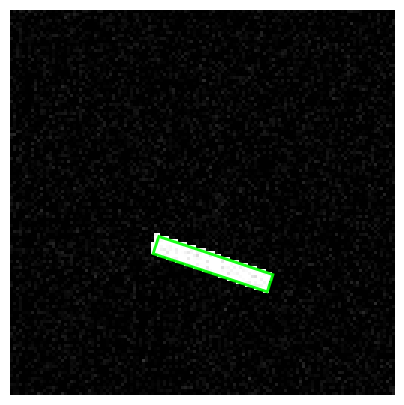

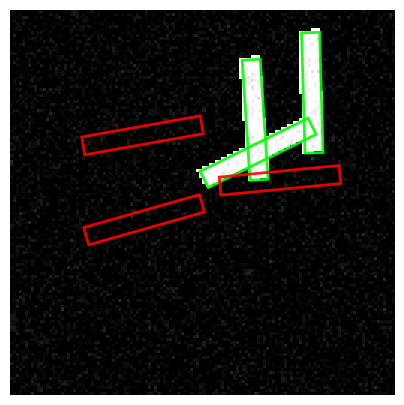

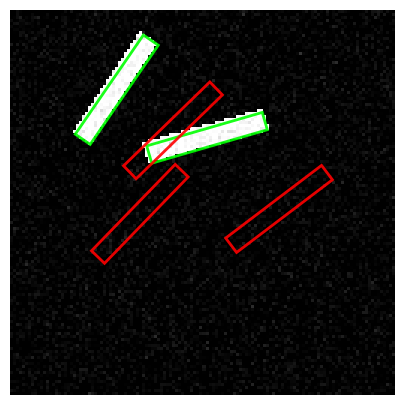

In [15]:
show_prediction(model, dataset, idx=0)
show_prediction(model, dataset, idx=5)
show_prediction(model, dataset, idx=17)

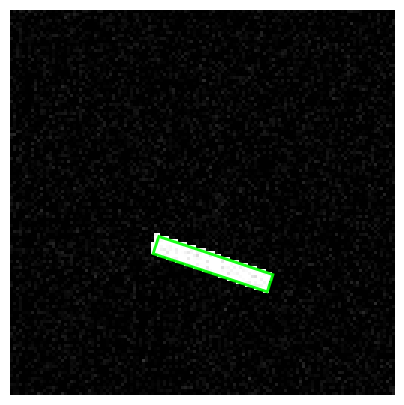

In [18]:
img, gt_boxes = dataset.base[0]

plt.figure(figsize=(5, 5))
plt.imshow(img.squeeze(), cmap="gray")
plt.axis("off")

w = dataset.base.rect_w
h = dataset.base.rect_h

for cx, cy, angle in gt_boxes:
    draw_rotated_rect(
        plt.gca(),
        cx, cy,
        w, h,
        angle,
        color="lime",
        lw=2
    )

plt.show()

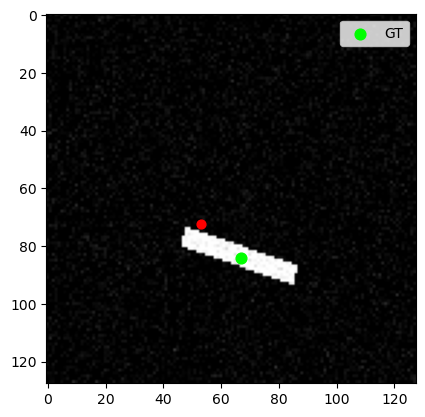

In [26]:
plt.imshow(img.squeeze(), cmap="gray")
plt.scatter(
    [cx for cx, cy, a in gt_boxes],
    [cy for cx, cy, a in gt_boxes],
    c="lime", s=60, label="GT"
)

pred = model(img.unsqueeze(0))[0].detach().numpy()
img_size = dataset.base.img_size

for cx_n, cy_n, a_n, conf in pred:
    if conf > 0.5:
        plt.scatter(cx_n * img_size, cy_n * img_size, c="red", s=40)

plt.legend()
plt.show()

In [27]:
img1, boxes1 = dataset.base[0]
img2, boxes2 = dataset.base[0]

print(torch.allclose(img1, img2))
print(boxes1, boxes2)


True
tensor([[67.0000, 84.0000,  0.3228]]) tensor([[67.0000, 84.0000,  0.3228]])


In [28]:
print("GT:", target[:, :2].cpu().numpy())
print("Pred:", pred[:, :2].detach().cpu().numpy())

GT: [[0.5234375 0.65625  ]
 [0.        0.       ]
 [0.        0.       ]]


AttributeError: 'numpy.ndarray' object has no attribute 'detach'